In [570]:
import pandas as pd
import numpy as np

df = pd.read_csv("crowd_dataset.csv")

df.head()

,event_type,time_slot,day_type,weather,weather_severity,event_size,venue_capacity,is_indoor,venue_size_sqm,entry_gates,...,bomb_threat,volunteers_assigned,base_required_volunteers,required_volunteers,volunteer_gap,reserve_volunteers,congestion_score,congestion_level,risk_score,risk_level
0,Sports Event,Afternoon,Weekend,Rain,2.0,Medium,16708.0,1,6994.0,11,...,0,88.0,110.0,115.0,27.0,16.0,29.2,Low,31.6,Dangerous
1,Railway Station,Morning,Weekend,Extreme Heat,1.2,Medium,3042.0,1,1095.0,5,...,0,22.0,26.0,31.0,9.0,3.0,32.4,Low,27.7,Warning
2,Airport Crowd,Evening,Weekday,Sunny,0.0,Mega,24454.0,1,9686.0,13,...,0,134.0,144.0,144.0,10.0,9.0,23.2,Low,24.8,Warning
3,Corporate Event,Evening,Weekday,Sunny,0.0,Small,418.0,1,150.0,2,...,0,2.0,3.0,4.0,2.0,1.0,30.5,Low,25.1,Warning
4,Corporate Event,Afternoon,Weekday,Cloudy,0.5,Small,302.0,1,150.0,2,...,0,2.0,3.0,4.0,2.0,1.0,14.1,Low,18.9,Safe


In [571]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 87 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_type                    10000 non-null  str    
 1   time_slot                     10000 non-null  str    
 2   day_type                      10000 non-null  str    
 3   weather                       10000 non-null  str    
 4   weather_severity              10000 non-null  float64
 5   event_size                    10000 non-null  str    
 6   venue_capacity                10000 non-null  float64
 7   is_indoor                     10000 non-null  int64  
 8   venue_size_sqm                10000 non-null  float64
 9   entry_gates                   10000 non-null  int64  
 10  emergency_gates               10000 non-null  int64  
 11  gate_width_m                  10000 non-null  float64
 12  gate_efficiency               10000 non-null  float64
 13  parking_capac

In [572]:
df.isnull().sum()

event_type            0
time_slot             0
day_type              0
weather               0
weather_severity      0
                     ..
reserve_volunteers    0
congestion_score      0
congestion_level      0
risk_score            0
risk_level            0
Length: 87, dtype: int64

In [573]:
import pickle

risk_mapping = {
    "Safe": 0,
    "Warning": 1,
    "Dangerous": 2
}

reverse_mapping = {
    0: "Safe",
    1: "Warning",
    2: "Dangerous"
}

df["risk_level"] = df["risk_level"].map(risk_mapping)

with open("risk_label_encoder.pkl", "wb") as file:
    pickle.dump(reverse_mapping, file)

df.head()

,event_type,time_slot,day_type,weather,weather_severity,event_size,venue_capacity,is_indoor,venue_size_sqm,entry_gates,...,bomb_threat,volunteers_assigned,base_required_volunteers,required_volunteers,volunteer_gap,reserve_volunteers,congestion_score,congestion_level,risk_score,risk_level
0,Sports Event,Afternoon,Weekend,Rain,2.0,Medium,16708.0,1,6994.0,11,...,0,88.0,110.0,115.0,27.0,16.0,29.2,Low,31.6,2
1,Railway Station,Morning,Weekend,Extreme Heat,1.2,Medium,3042.0,1,1095.0,5,...,0,22.0,26.0,31.0,9.0,3.0,32.4,Low,27.7,1
2,Airport Crowd,Evening,Weekday,Sunny,0.0,Mega,24454.0,1,9686.0,13,...,0,134.0,144.0,144.0,10.0,9.0,23.2,Low,24.8,1
3,Corporate Event,Evening,Weekday,Sunny,0.0,Small,418.0,1,150.0,2,...,0,2.0,3.0,4.0,2.0,1.0,30.5,Low,25.1,1
4,Corporate Event,Afternoon,Weekday,Cloudy,0.5,Small,302.0,1,150.0,2,...,0,2.0,3.0,4.0,2.0,1.0,14.1,Low,18.9,0


In [574]:
features = [
    "crowd_count",
    "occupancy_pct",
    "queue_length",
    "avg_waiting_time_min",
    "weather",
    "weather_severity",
    "crowd_behavior",
    "medical_incidents",
    "security_incidents",
    "fire_alarm",
    "stampede_alert",
    "bomb_threat",
    "emergency_evacuation",
    "volunteer_gap",
    "camera_failure",
    "network_failure",
    "power_failure",
    "road_traffic_index",
    "visibility_km"
]

x = df[features]
y = df["risk_level"]

In [575]:
x = pd.get_dummies(x)

In [576]:
numeric_cols = [
    "crowd_count",
    "occupancy_pct",
    "queue_length",
    "avg_waiting_time_min",
    "weather_severity",
    "medical_incidents",
    "security_incidents",
    "fire_alarm",
    "stampede_alert",
    "bomb_threat",
    "emergency_evacuation",
    "volunteer_gap",
    "camera_failure",
    "network_failure",
    "power_failure",
    "road_traffic_index",
    "visibility_km"
]

In [577]:
categorical_cols = [
    "weather",
    "crowd_behavior"
]

In [578]:
print(x.columns.tolist())

['crowd_count', 'occupancy_pct', 'queue_length', 'avg_waiting_time_min', 'weather_severity', 'medical_incidents', 'security_incidents', 'fire_alarm', 'stampede_alert', 'bomb_threat', 'emergency_evacuation', 'volunteer_gap', 'camera_failure', 'network_failure', 'power_failure', 'road_traffic_index', 'visibility_km', 'weather_Cloudy', 'weather_Extreme Heat', 'weather_Fog', 'weather_Rain', 'weather_Storm', 'weather_Sunny', 'crowd_behavior_Aggressive', 'crowd_behavior_Calm', 'crowd_behavior_Normal', 'crowd_behavior_Panic']


In [579]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x[numeric_cols] = scaler.fit_transform(x[numeric_cols])

x.head()

,crowd_count,occupancy_pct,queue_length,avg_waiting_time_min,weather_severity,medical_incidents,security_incidents,fire_alarm,stampede_alert,bomb_threat,...,weather_Cloudy,weather_Extreme Heat,weather_Fog,weather_Rain,weather_Storm,weather_Sunny,crowd_behavior_Aggressive,crowd_behavior_Calm,crowd_behavior_Normal,crowd_behavior_Panic
0,0.326563,0.328816,-0.169447,1.310785,1.040703,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,True,False,False,True,False,False,False
1,-0.466105,0.936022,-0.154339,1.179452,0.261843,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,True,False,False,False,False,False,False,True,False
2,0.655273,-0.065335,-0.169447,0.227285,-0.906447,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,False,False,True,False,True,False,False
3,-0.653241,-0.374265,-0.148845,0.424285,-0.906447,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,False,False,True,False,True,False,False
4,-0.662195,-1.114630,-0.169447,-0.133881,-0.419660,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,True,False,False,False,False,False,False,True,False,False


In [580]:
import pickle

pickle.dump(
    scaler,
    open("risk_scaler.pkl","wb")
)

In [581]:
df["risk_level"].value_counts()

risk_level
0    4499
1    3470
2    2031
Name: count, dtype: int64

In [582]:
print(x.columns.tolist())

['crowd_count', 'occupancy_pct', 'queue_length', 'avg_waiting_time_min', 'weather_severity', 'medical_incidents', 'security_incidents', 'fire_alarm', 'stampede_alert', 'bomb_threat', 'emergency_evacuation', 'volunteer_gap', 'camera_failure', 'network_failure', 'power_failure', 'road_traffic_index', 'visibility_km', 'weather_Cloudy', 'weather_Extreme Heat', 'weather_Fog', 'weather_Rain', 'weather_Storm', 'weather_Sunny', 'crowd_behavior_Aggressive', 'crowd_behavior_Calm', 'crowd_behavior_Normal', 'crowd_behavior_Panic']


In [583]:
from sklearn.model_selection import train_test_split

X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    
)

In [584]:
print("X_train shape :", X_train_risk.shape)
print("X_test shape  :", X_test_risk.shape)
print("y_train shape :", y_train_risk.shape)
print("y_test shape  :", y_test_risk.shape)

X_train shape : (8000, 27)
X_test shape  : (2000, 27)
y_train shape : (8000,)
y_test shape  : (2000,)


In [585]:
x.head()

,crowd_count,occupancy_pct,queue_length,avg_waiting_time_min,weather_severity,medical_incidents,security_incidents,fire_alarm,stampede_alert,bomb_threat,...,weather_Cloudy,weather_Extreme Heat,weather_Fog,weather_Rain,weather_Storm,weather_Sunny,crowd_behavior_Aggressive,crowd_behavior_Calm,crowd_behavior_Normal,crowd_behavior_Panic
0,0.326563,0.328816,-0.169447,1.310785,1.040703,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,True,False,False,True,False,False,False
1,-0.466105,0.936022,-0.154339,1.179452,0.261843,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,True,False,False,False,False,False,False,True,False
2,0.655273,-0.065335,-0.169447,0.227285,-0.906447,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,False,False,True,False,True,False,False
3,-0.653241,-0.374265,-0.148845,0.424285,-0.906447,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,False,False,False,False,False,True,False,True,False,False
4,-0.662195,-1.114630,-0.169447,-0.133881,-0.419660,-0.236235,-0.207684,-0.065716,-0.034662,-0.020004,...,True,False,False,False,False,False,False,True,False,False


Train Risk Prediction Models

Train models to predict:

Safe / Warning / Dangerous

In [586]:
print(df["risk_level"].value_counts())

risk_level
0    4499
1    3470
2    2031
Name: count, dtype: int64


In [587]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=42
)

logistic_model.fit(
    X_train_risk,
    y_train_risk
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [588]:
y_pred_logistic = logistic_model.predict(
    X_test_risk
)

In [589]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(
    y_test_risk,
    y_pred_logistic
)

print("Logistic Accuracy :", accuracy)

Logistic Accuracy : 0.742


In [590]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(
    y_test_risk,
    y_pred_logistic
)
print(conf_matrix)

[[753 132   2]
 [185 434  63]
 [  2 132 297]]


correct predictions = diagonal        


mistakes = outside diagonal

In [591]:
from sklearn.metrics import classification_report
class_report = classification_report(
    y_test_risk,
    y_pred_logistic
)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       887
           1       0.62      0.64      0.63       682
           2       0.82      0.69      0.75       431

    accuracy                           0.74      2000
   macro avg       0.75      0.72      0.73      2000
weighted avg       0.74      0.74      0.74      2000



In [592]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=15,
    min_samples_leaf=8,
    random_state=42
)

dt_model.fit(X_train_risk, y_train_risk)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [593]:
y_pred_tree = dt_model.predict(X_test_risk)

In [594]:
from sklearn.metrics import accuracy_score
tree_accuracy = accuracy_score(y_test_risk, y_pred_tree)
print("Accuracy:", tree_accuracy)

Accuracy: 0.6955


In [595]:
from sklearn.metrics import confusion_matrix
tree_conf_matrix = confusion_matrix(y_test_risk, y_pred_tree)
print("tree Confusion Matrix:")
print(tree_conf_matrix)

tree Confusion Matrix:
[[722 160   5]
 [215 387  80]
 [ 15 134 282]]


In [596]:
from sklearn.metrics import classification_report
tree_class_report = classification_report(y_test_risk, y_pred_tree)
print("tree Classification Report:")
print(tree_class_report)

tree Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79       887
           1       0.57      0.57      0.57       682
           2       0.77      0.65      0.71       431

    accuracy                           0.70      2000
   macro avg       0.70      0.68      0.69      2000
weighted avg       0.70      0.70      0.69      2000



In [597]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_risk,
    y_train_risk
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [598]:
y_pred_rf= rf_model.predict(X_test_risk)

In [599]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test_risk, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7365


In [600]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test_risk, y_pred_rf)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[749 135   3]
 [188 439  55]
 [  3 143 285]]


In [601]:
from sklearn.metrics import classification_report
class_report = classification_report(y_test_risk, y_pred_rf)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       887
           1       0.61      0.64      0.63       682
           2       0.83      0.66      0.74       431

    accuracy                           0.74      2000
   macro avg       0.75      0.72      0.73      2000
weighted avg       0.74      0.74      0.74      2000



check overfitting or not


In [602]:
from sklearn.metrics import accuracy_score

train_prediction = logistic_model.predict(X_train_risk)
test_prediction = logistic_model.predict(X_test_risk)

train_accuracy = accuracy_score(y_train_risk, train_prediction)
test_accuracy = accuracy_score(y_test_risk, test_prediction)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.7485
Testing Accuracy  : 0.742


In [603]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)

print("Average Accuracy :", scores.mean())

[0.716  0.7305 0.7295 0.7395 0.7385]
Average Accuracy : 0.7308000000000001


Selected decision tree as CrowdShield AI risk prediction model

hyperparameter tune

In [604]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf1 = RandomForestClassifier(random_state=42,n_estimators=100,max_depth=10)
rf1.fit(X_train_risk, y_train_risk)
y_pred_rf1 = rf1.predict(X_test_risk)
rf1_accuracy = accuracy_score(y_test_risk, y_pred_rf1)
print("Random Forest Accuracy:", rf1_accuracy)


Random Forest Accuracy: 0.723


In [605]:
importance = pd.DataFrame({
    "Feature": X_train_risk.columns,
    "Coefficient": logistic_model.coef_[2]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance.head(20)

,Feature,Coefficient
2,queue_length,2.451974
1,occupancy_pct,1.678968
3,avg_waiting_time_min,1.207141
5,medical_incidents,0.906095
4,weather_severity,0.867045
11,volunteer_gap,0.770139
6,security_incidents,0.476066
10,emergency_evacuation,0.276077
21,weather_Storm,0.238219
15,road_traffic_index,0.104751


In [606]:
corr = df.select_dtypes(include="number").corr()

corr["risk_level"].sort_values(ascending=False)

risk_level                     1.000000
risk_score                     0.850268
congestion_score               0.704619
avg_waiting_time_min           0.506114
occupancy_pct                  0.461672
                                 ...   
temperature_c                 -0.141355
ai_detection_confidence_pct   -0.210878
visibility_km                 -0.330918
gate_efficiency               -0.361195
avg_walking_speed_mps         -0.408226
Name: risk_level, Length: 79, dtype: float64

Save best model

In [607]:
import pickle
with open('risk_model.pkl', 'wb') as file:
    pickle.dump(logistic_model, file)

Congestion prediction

In [608]:
x = df[[
    "crowd_count",
    "occupancy_pct",
    "arrival_rate_per_min",
    "entry_rate_per_min",
    "queue_length",
    "avg_waiting_time_min",
    "entry_gates",
    "gate_efficiency",
    "weather",
    "weather_severity",
    "visibility_km",
    "road_traffic_index",
    "parking_occupancy_pct",
    "crowd_density_per_sqm",
    "crowd_behavior",
    "camera_coverage_pct",
    "volunteer_gap",
    "medical_incidents",
    "security_incidents"
]]

y = df["congestion_level"]

In [609]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y.head()

0    Low
1    Low
2    Low
3    Low
4    Low
Name: congestion_level, dtype: str

In [610]:
import pickle

with open(
    "congestion_label_encoder.pkl",
    "wb"
) as file:

    pickle.dump(
        label_encoder,
        file
    )

In [611]:
x = pd.get_dummies(
    x,
    columns=[
        "weather",
        "crowd_behavior"
    ]
)

In [612]:
print(x.columns.tolist())

['crowd_count', 'occupancy_pct', 'arrival_rate_per_min', 'entry_rate_per_min', 'queue_length', 'avg_waiting_time_min', 'entry_gates', 'gate_efficiency', 'weather_severity', 'visibility_km', 'road_traffic_index', 'parking_occupancy_pct', 'crowd_density_per_sqm', 'camera_coverage_pct', 'volunteer_gap', 'medical_incidents', 'security_incidents', 'weather_Cloudy', 'weather_Extreme Heat', 'weather_Fog', 'weather_Rain', 'weather_Storm', 'weather_Sunny', 'crowd_behavior_Aggressive', 'crowd_behavior_Calm', 'crowd_behavior_Normal', 'crowd_behavior_Panic']


In [613]:
x.head()

,crowd_count,occupancy_pct,arrival_rate_per_min,entry_rate_per_min,queue_length,avg_waiting_time_min,entry_gates,gate_efficiency,weather_severity,visibility_km,...,weather_Cloudy,weather_Extreme Heat,weather_Fog,weather_Rain,weather_Storm,weather_Sunny,crowd_behavior_Aggressive,crowd_behavior_Calm,crowd_behavior_Normal,crowd_behavior_Panic
0,13449.076136,80.5,575.4,575.4,0.0,9.0,11,0.896527,2.0,6.89,...,False,False,False,True,False,False,True,False,False,False
1,2796.410039,91.9,30.4,30.4,11.0,8.6,5,0.916517,1.2,9.77,...,False,True,False,False,False,False,False,False,True,False
2,17866.601352,73.1,746.8,746.8,0.0,5.7,13,0.990000,0.0,10.00,...,False,False,False,False,False,True,False,True,False,False
3,281.480235,67.3,13.5,13.5,15.0,6.3,2,0.912638,0.0,10.00,...,False,False,False,False,False,True,False,True,False,False
4,161.153052,53.4,1.9,1.9,0.0,4.6,2,0.941372,0.5,8.90,...,True,False,False,False,False,False,False,True,False,False


In [614]:
numeric_cols = [

    "crowd_count",
    "occupancy_pct",
    "arrival_rate_per_min",
    "entry_rate_per_min",
    "queue_length",
    "avg_waiting_time_min",
    "entry_gates",
    "gate_efficiency",
    "weather_severity",
    "visibility_km",
    "road_traffic_index",
    "parking_occupancy_pct",
    "crowd_density_per_sqm",
    "camera_coverage_pct",
    "volunteer_gap",
    "medical_incidents",
    "security_incidents"

]

In [615]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
x[numeric_cols] = scaler.fit_transform(x[numeric_cols])
x.head()


,crowd_count,occupancy_pct,arrival_rate_per_min,entry_rate_per_min,queue_length,avg_waiting_time_min,entry_gates,gate_efficiency,weather_severity,visibility_km,...,weather_Cloudy,weather_Extreme Heat,weather_Fog,weather_Rain,weather_Storm,weather_Sunny,crowd_behavior_Aggressive,crowd_behavior_Calm,crowd_behavior_Normal,crowd_behavior_Panic
0,0.326563,0.328816,0.568395,0.766767,-0.169447,1.310785,0.743402,0.077178,1.040703,-0.462081,...,False,False,False,True,False,False,True,False,False,False
1,-0.466105,0.936022,-0.463315,-0.515684,-0.154339,1.179452,-0.535936,0.367910,0.261843,0.844712,...,False,True,False,False,False,False,False,False,True,False
2,0.655273,-0.065335,0.892864,1.170092,-0.169447,0.227285,1.169848,1.436601,-0.906447,0.949075,...,False,False,False,False,False,True,False,True,False,False
3,-0.653241,-0.374265,-0.495308,-0.555452,-0.148845,0.424285,-1.175605,0.311489,-0.906447,0.949075,...,False,False,False,False,False,True,False,True,False,False
4,-0.662195,-1.114630,-0.517267,-0.582748,-0.169447,-0.133881,-1.175605,0.729379,-0.419660,0.449952,...,True,False,False,False,False,False,False,True,False,False


In [616]:
import pickle

with open("congestion_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [617]:
print(df["congestion_level"].value_counts())


congestion_level
Low       8514
Medium    1402
High        84
Name: count, dtype: int64


In [618]:
X_train_congestion, X_test_congestion, y_train_congestion, y_test_congestion = train_test_split(
    x,
    y_encoded,
    test_size=0.2,
    random_state=42,
    
)

In [619]:
print("X_train shape:", X_train_congestion.shape)
print("X_test shape:", X_test_congestion.shape)    
print("y_train shape:", y_train_congestion.shape)
print("y_test shape:", y_test_congestion.shape)

X_train shape: (8000, 27)
X_test shape: (2000, 27)
y_train shape: (8000,)
y_test shape: (2000,)


In [620]:
print(x.columns.tolist())

['crowd_count', 'occupancy_pct', 'arrival_rate_per_min', 'entry_rate_per_min', 'queue_length', 'avg_waiting_time_min', 'entry_gates', 'gate_efficiency', 'weather_severity', 'visibility_km', 'road_traffic_index', 'parking_occupancy_pct', 'crowd_density_per_sqm', 'camera_coverage_pct', 'volunteer_gap', 'medical_incidents', 'security_incidents', 'weather_Cloudy', 'weather_Extreme Heat', 'weather_Fog', 'weather_Rain', 'weather_Storm', 'weather_Sunny', 'crowd_behavior_Aggressive', 'crowd_behavior_Calm', 'crowd_behavior_Normal', 'crowd_behavior_Panic']


In [621]:

from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=42
)
lg_model.fit(X_train_congestion, y_train_congestion)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [622]:
lg_y_pred = lg_model.predict(X_test_congestion)

In [623]:
from sklearn.metrics import accuracy_score
logistic_accuracy = accuracy_score(y_test_congestion, lg_y_pred)
print("logistic regression Accuracy:", logistic_accuracy)

logistic regression Accuracy: 0.928


In [624]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test_congestion, lg_y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[  13    0    8]
 [   0 1644   40]
 [   7   89  199]]


In [625]:
from sklearn.metrics import classification_report
class_report = classification_report(y_test_congestion, lg_y_pred)
print("Classification Report:") 
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63        21
           1       0.95      0.98      0.96      1684
           2       0.81      0.67      0.73       295

    accuracy                           0.93      2000
   macro avg       0.80      0.76      0.78      2000
weighted avg       0.92      0.93      0.93      2000



In [626]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=15,
    min_samples_leaf=8,
    random_state=42
)
dt_model.fit(X_train_congestion, y_train_congestion)  

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [627]:
y_pred_dt = dt_model.predict(X_test_congestion)

In [628]:
dt_accuracy = accuracy_score(y_test_congestion, y_pred_dt)
print("Accuracy:", dt_accuracy)

Accuracy: 0.9085


In [629]:
conf_matrix_dt = confusion_matrix(y_test_congestion, y_pred_dt)
print("Confusion Matrix:")
print(conf_matrix_dt)


Confusion Matrix:
[[  15    0    6]
 [   0 1621   63]
 [   2  112  181]]


In [630]:
clssification_report_dt = classification_report(y_test_congestion, y_pred_dt)
print("Classification Report:")
print(clssification_report_dt)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79        21
           1       0.94      0.96      0.95      1684
           2       0.72      0.61      0.66       295

    accuracy                           0.91      2000
   macro avg       0.85      0.76      0.80      2000
weighted avg       0.90      0.91      0.91      2000



In [631]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
rfc_model.fit(X_train_congestion, y_train_congestion) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [632]:
y_pred_rfc = rfc_model.predict(
    X_test_congestion
)

In [633]:
rfc_accuracy = accuracy_score(y_test_congestion, y_pred_rfc)
print("Accuracy:", rfc_accuracy)

Accuracy: 0.9215


In [634]:
confusion_matrix_rfc = confusion_matrix(y_test_congestion, y_pred_rfc)
print("Confusion Matrix:")  
print(confusion_matrix_rfc)

Confusion Matrix:
[[  10    0   11]
 [   0 1656   28]
 [   3  115  177]]


In [635]:
class_report_rfc = classification_report(y_test_congestion, y_pred_rfc)
print("Classification Report:")
print(class_report_rfc)

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.48      0.59        21
           1       0.94      0.98      0.96      1684
           2       0.82      0.60      0.69       295

    accuracy                           0.92      2000
   macro avg       0.84      0.69      0.75      2000
weighted avg       0.92      0.92      0.92      2000



check overfitting

In [636]:
train_accuracy_dt = dt_model.score(
    X_train_congestion,
    y_train_congestion
)

test_accuracy_dt = dt_model.score(
    X_test_congestion,
    y_test_congestion
)

print("Decision Tree")
print("Train Accuracy :", train_accuracy_dt)
print("Test Accuracy  :", test_accuracy_dt)

Decision Tree
Train Accuracy : 0.9555
Test Accuracy  : 0.9085


In [637]:
train_accuracy_rf = rfc_model.score(
    X_train_congestion,
    y_train_congestion
)

test_accuracy_rf = rfc_model.score(
    X_test_congestion,
    y_test_congestion
)

print("Random Forest")
print("Train Accuracy :", train_accuracy_rf)
print("Test Accuracy  :", test_accuracy_rf)

Random Forest
Train Accuracy : 0.9675
Test Accuracy  : 0.9215


In [638]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_congestion,
    y_pred_rfc
))

              precision    recall  f1-score   support

           0       0.77      0.48      0.59        21
           1       0.94      0.98      0.96      1684
           2       0.82      0.60      0.69       295

    accuracy                           0.92      2000
   macro avg       0.84      0.69      0.75      2000
weighted avg       0.92      0.92      0.92      2000



In [639]:
import pickle

with open("congestion_model.pkl", "wb") as file:
    pickle.dump(lg_model, file)

Regression Models

Waiting Time Prediction

In [640]:
print(df.columns.tolist())

['event_type', 'time_slot', 'day_type', 'weather', 'weather_severity', 'event_size', 'venue_capacity', 'is_indoor', 'venue_size_sqm', 'entry_gates', 'emergency_gates', 'gate_width_m', 'gate_efficiency', 'parking_capacity', 'camera_count', 'crowd_count', 'occupancy_pct', 'arrival_rate_per_min', 'entry_rate_per_min', 'exit_rate_per_min', 'gate_throughput_per_gate', 'is_peak_hour', 'crowd_density_per_sqm', 'avg_walking_speed_mps', 'crowd_behavior_index', 'crowd_behavior', 'family_pct', 'children_pct', 'senior_citizen_pct', 'vip_pct', 'disabled_pct', 'security_guards', 'police_personnel', 'medical_staff', 'fire_team', 'emergency_response_team', 'qr_scan_time_sec', 'security_check_time_sec', 'metal_detector_delay_sec', 'bag_check_delay_sec', 'ticket_verification_time_sec', 'manual_verification_pct', 'qr_failure_rate_pct', 'device_failure_pct', 'queue_length', 'queue_growth_rate_per_min', 'queue_reduction_rate_per_min', 'avg_waiting_time_min', 'max_waiting_time_min', 'ai_detection_confidence

In [641]:
y = df["avg_waiting_time_min"]
X = df[
[
   "crowd_count",
"occupancy_pct",
"arrival_rate_per_min",
"entry_rate_per_min",
"queue_length",
"entry_gates",
"gate_width_m",
"gate_efficiency",
"security_check_time_sec",
"metal_detector_delay_sec",
"bag_check_delay_sec",
"ticket_verification_time_sec",
"manual_verification_pct",
"qr_failure_rate_pct",
"device_failure_pct",
"weather",
"weather_severity",
"visibility_km",
"volunteers_assigned",
"base_required_volunteers",
"is_peak_hour",
"queue_growth_rate_per_min",
"queue_reduction_rate_per_min",
"qr_scan_time_sec",
]
]

In [642]:
corr = df.corr(numeric_only=True)["avg_waiting_time_min"].sort_values(ascending=False)
print(corr.head(20))

avg_waiting_time_min            1.000000
max_waiting_time_min            0.812513
congestion_score                0.644829
risk_score                      0.569915
risk_level                      0.506114
weather_severity                0.501189
qr_failure_rate_pct             0.489479
device_failure_pct              0.471013
manual_verification_pct         0.464124
rain_intensity_mm_hr            0.447239
is_peak_hour                    0.425016
qr_scan_time_sec                0.406172
humidity_pct                    0.379033
wind_speed_kmh                  0.353078
ticket_verification_time_sec    0.336871
queue_length                    0.306045
queue_growth_rate_per_min       0.232933
volunteer_gap                   0.228523
arrival_rate_per_min            0.200871
queue_reduction_rate_per_min    0.165938
Name: avg_waiting_time_min, dtype: float64


In [643]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [644]:
waiting_feature_names = X.columns.tolist()

In [645]:
from sklearn.model_selection import train_test_split

X_train_wt, X_test_wt, y_train_wt, y_test_wt = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [646]:
from sklearn.preprocessing import StandardScaler

waiting_scaler = StandardScaler()

numeric_columns = X_train_wt.select_dtypes(
    include=["int64", "float64"]
).columns

X_train_wt[numeric_columns] = waiting_scaler.fit_transform(
    X_train_wt[numeric_columns]
)

X_test_wt[numeric_columns] = waiting_scaler.transform(
    X_test_wt[numeric_columns]
)

In [647]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train_wt,
    y_train_wt
)

y_pred_lr = lr.predict(
    X_test_wt
)

In [648]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(
    y_test_wt,
    y_pred_lr
)

mse = mean_squared_error(
    y_test_wt,
    y_pred_lr
)

r2 = r2_score(
    y_test_wt,
    y_pred_lr
)

print("Mean Absolute Error:", round(mae,3))
print("Mean Squared Error:", round(mse,3))
print("R² Score:", round(r2,3))

Mean Absolute Error: 1.664
Mean Squared Error: 4.864
R² Score: 0.513


In [649]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt.fit(
    X_train_wt,
    y_train_wt
)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [650]:

y_pred_dt = dt.predict(
    X_test_wt
)

In [651]:

print("Decision Tree")

print("MAE :", round(mean_absolute_error(y_test_wt,y_pred_dt),3))

print("MSE :", round(mean_squared_error(y_test_wt,y_pred_dt),3))

print("R² :", round(r2_score(y_test_wt,y_pred_dt),3))

Decision Tree
MAE : 1.778
MSE : 5.294
R² : 0.47


In [652]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=10
)

rf.fit(
    X_train_wt,
    y_train_wt
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [653]:

y_pred_rf = rf.predict(
    X_test_wt
)

In [654]:

print("Random Forest")

print("MAE :", round(mean_absolute_error(y_test_wt,y_pred_rf),3))

print("MSE :", round(mean_squared_error(y_test_wt,y_pred_rf),3))

print("R² :", round(r2_score(y_test_wt,y_pred_rf),3))

Random Forest
MAE : 1.599
MSE : 4.134
R² : 0.586


In [655]:
corr = df.corr(numeric_only=True)

print(
    corr["avg_waiting_time_min"]
    .sort_values(ascending=False)
)

avg_waiting_time_min           1.000000
max_waiting_time_min           0.812513
congestion_score               0.644829
risk_score                     0.569915
risk_level                     0.506114
                                 ...   
temperature_c                 -0.176876
ai_detection_confidence_pct   -0.253229
visibility_km                 -0.400065
avg_walking_speed_mps         -0.438099
gate_efficiency               -0.443579
Name: avg_waiting_time_min, Length: 79, dtype: float64


In [656]:
import pickle

with open("waiting_time_scaler.pkl", "wb") as file:
    pickle.dump(waiting_scaler, file)

In [657]:
import pickle

with open("waiting_time_model.pkl", "wb") as file:
    pickle.dump(rf, file)

congestion-score prediction

In [658]:
y = df["congestion_score"]
X = df[[
    "crowd_count",
    "occupancy_pct",
    "arrival_rate_per_min",
    "entry_rate_per_min",
    "queue_length",
    "avg_waiting_time_min",
    "entry_gates",
    "gate_efficiency",
    "weather",
    "weather_severity",
    "visibility_km",
    "road_traffic_index",
    "parking_occupancy_pct",
    "crowd_density_per_sqm",
    "crowd_behavior",
    "camera_coverage_pct",
    "volunteer_gap",
    "medical_incidents",
    "security_incidents",
    "is_peak_hour"
]]

In [659]:
X = pd.get_dummies(
    X,
    drop_first=True
)

congestion_score_feature_names = X.columns.tolist()

In [660]:
from sklearn.preprocessing import StandardScaler

congestion_score_scaler = StandardScaler()

numeric_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

X[numeric_cols] = congestion_score_scaler.fit_transform(
    X[numeric_cols]
)

In [661]:
import pickle

with open("congestion_score_scaler.pkl","wb") as file:
    pickle.dump(congestion_score_scaler,file)

In [662]:
from sklearn.model_selection import train_test_split

X_train_con_score, X_test_con_score, y_train_con_score, y_test_con_score = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [663]:
from sklearn.linear_model import LinearRegression

lin_model_con = LinearRegression()

lin_model_con.fit(
    X_train_con_score,
    y_train_con_score
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [664]:
y_pred_lin = lin_model_con.predict(
    X_test_con_score
)

In [665]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Linear Regression")

print("MAE :",mean_absolute_error(
    y_test_con_score,
    y_pred_lin
))

print("MSE :",mean_squared_error(
    y_test_con_score,
    y_pred_lin
))

print("R2 :",r2_score(
    y_test_con_score,
    y_pred_lin
))

Linear Regression
MAE : 2.561489413258703
MSE : 11.200168444954247
R2 : 0.8817436571604016


In [666]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dt_con = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

dt_con.fit(
    X_train_con_score,
    y_train_con_score
)

y_pred_dt = dt_con.predict(
    X_test_con_score
)

print("Decision Tree Regressor")
print("MAE :", mean_absolute_error(y_test_con_score, y_pred_dt))
print("MSE :", mean_squared_error(y_test_con_score, y_pred_dt))
print("R2  :", r2_score(y_test_con_score, y_pred_dt))

Decision Tree Regressor
MAE : 2.950814996430067
MSE : 14.026102459208525
R2  : 0.8519061932620539


In [667]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_con = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_con.fit(
    X_train_con_score,
    y_train_con_score
)

y_pred_rf = rf_con.predict(
    X_test_con_score
)

print("Random Forest Regressor")
print("MAE :", mean_absolute_error(y_test_con_score, y_pred_rf))
print("MSE :", mean_squared_error(y_test_con_score, y_pred_rf))
print("R2  :", r2_score(y_test_con_score, y_pred_rf))

Random Forest Regressor
MAE : 2.587262615489931
MSE : 10.76715943286342
R2  : 0.8863155582383285


In [668]:
import pickle
with open('congestion_score_model.pkl', 'wb') as file:
    pickle.dump(rf_con, file)

How many volunteers are needed?

In [669]:
y = df["required_volunteers"]

X = df[[
    "crowd_count",
    "occupancy_pct",
    "arrival_rate_per_min",
    "entry_rate_per_min",
    "queue_length",
    "weather",
    "weather_severity",
    "medical_incidents",
    "security_incidents",
    "entry_gates",
    "gate_efficiency",
    "is_peak_hour",
    "crowd_behavior",
    "venue_capacity"
]]

In [670]:
X = pd.get_dummies(
    X,
    columns=[
        "weather",
        "crowd_behavior"
    ],
    drop_first=True
)

volunteer_feature_names = X.columns.tolist()
X.head()

,crowd_count,occupancy_pct,arrival_rate_per_min,entry_rate_per_min,queue_length,weather_severity,medical_incidents,security_incidents,entry_gates,gate_efficiency,is_peak_hour,venue_capacity,weather_Extreme Heat,weather_Fog,weather_Rain,weather_Storm,weather_Sunny,crowd_behavior_Calm,crowd_behavior_Normal,crowd_behavior_Panic
0,13449.076136,80.5,575.4,575.4,0.0,2.0,0,0,11,0.896527,1,16708.0,False,False,True,False,False,False,False,False
1,2796.410039,91.9,30.4,30.4,11.0,1.2,0,0,5,0.916517,0,3042.0,True,False,False,False,False,False,True,False
2,17866.601352,73.1,746.8,746.8,0.0,0.0,0,0,13,0.990000,1,24454.0,False,False,False,False,True,True,False,False
3,281.480235,67.3,13.5,13.5,15.0,0.0,0,0,2,0.912638,1,418.0,False,False,False,False,True,True,False,False
4,161.153052,53.4,1.9,1.9,0.0,0.5,0,0,2,0.941372,0,302.0,False,False,False,False,False,True,False,False


In [671]:
from sklearn.preprocessing import StandardScaler

volunteer_scaler = StandardScaler()

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

X[numeric_cols] = volunteer_scaler.fit_transform(
    X[numeric_cols]
)

In [672]:
import pickle

with open("volunteer_scaler.pkl", "wb") as file:
    pickle.dump(volunteer_scaler, file)

In [673]:
from sklearn.model_selection import train_test_split

X_train_vol, X_test_vol, y_train_vol, y_test_vol = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [674]:
from sklearn.linear_model import LinearRegression

lr_vol = LinearRegression()

lr_vol.fit(
    X_train_vol,
    y_train_vol
)

y_pred_lr = lr_vol.predict(
    X_test_vol
)

In [675]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test_vol, y_pred_lr))
print("MSE :", mean_squared_error(y_test_vol, y_pred_lr))
print("R2  :", r2_score(y_test_vol, y_pred_lr))

Linear Regression
MAE : 1.5449341455169356
MSE : 4.7881918426344345
R2  : 0.9996991059444508


In [676]:
from sklearn.ensemble import RandomForestRegressor

rf_vol = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_vol.fit(
    X_train_vol,
    y_train_vol
)

y_pred_rf = rf_vol.predict(
    X_test_vol
)

print("Random Forest Regressor")

print("MAE :", mean_absolute_error(y_test_vol, y_pred_rf))
print("MSE :", mean_squared_error(y_test_vol, y_pred_rf))
print("R2  :", r2_score(y_test_vol, y_pred_rf))

Random Forest Regressor
MAE : 2.1820132164118045
MSE : 85.47859932094242
R2  : 0.994628451979861


In [677]:
import pickle
with open('volunteer_model.pkl', 'wb') as file:
    pickle.dump(rf_vol, file)

Clustering Analysis

Detect overloaded gate groups


In [678]:
cluster_df = df[[
    "crowd_count",
    "occupancy_pct",
    "queue_length",
    "avg_waiting_time_min",
    "congestion_score",
    "risk_score",
    "crowd_density_per_sqm",
    "volunteer_gap"
]]

In [679]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_df)

WCSS = Within Cluster Sum of Squares


Lower WCSS means tighter, better-formed clusters.

how close the data points are to the center (centroid) of their cluster.

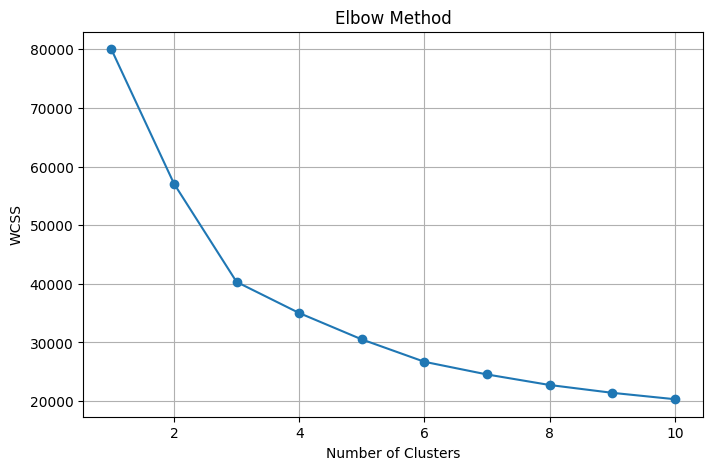

In [680]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

Best number of clusters : 4

Compares the WCSS from all 10 runs.
Keeps the solution with the lowest WCSS. n_init works like this

In [681]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Crowd_Cluster"] = kmeans.fit_predict(cluster_scaled)

In [682]:
import pandas as pd

cluster_centers = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_df.columns
)

cluster_centers

,crowd_count,occupancy_pct,queue_length,avg_waiting_time_min,congestion_score,risk_score,crowd_density_per_sqm,volunteer_gap
0,4658.682838,60.679134,4.227284,3.331588,20.184697,18.500076,1.656428,7.978606
1,40392.824506,95.214510,4185.917647,10.641961,61.046275,48.819216,2.564588,230.180392
2,5997.487340,69.132322,22.374173,7.812913,31.304317,28.198172,1.852863,13.180863
3,14487.738245,93.773602,28.739144,4.386286,30.628054,27.350640,2.538910,25.682599


In [683]:
print(cluster_centers)


    crowd_count  occupancy_pct  queue_length  avg_waiting_time_min  \
0   4658.682838      60.679134      4.227284              3.331588   
1  40392.824506      95.214510   4185.917647             10.641961   
2   5997.487340      69.132322     22.374173              7.812913   
3  14487.738245      93.773602     28.739144              4.386286   

   congestion_score  risk_score  crowd_density_per_sqm  volunteer_gap  
0         20.184697   18.500076               1.656428       7.978606  
1         61.046275   48.819216               2.564588     230.180392  
2         31.304317   28.198172               1.852863      13.180863  
3         30.628054   27.350640               2.538910      25.682599  


In [684]:
cluster_centers.sort_values("crowd_count")

,crowd_count,occupancy_pct,queue_length,avg_waiting_time_min,congestion_score,risk_score,crowd_density_per_sqm,volunteer_gap
0,4658.682838,60.679134,4.227284,3.331588,20.184697,18.500076,1.656428,7.978606
2,5997.487340,69.132322,22.374173,7.812913,31.304317,28.198172,1.852863,13.180863
3,14487.738245,93.773602,28.739144,4.386286,30.628054,27.350640,2.538910,25.682599
1,40392.824506,95.214510,4185.917647,10.641961,61.046275,48.819216,2.564588,230.180392


In [685]:
cluster_map = {
    0: "Low Crowd",
    2: "Medium Crowd",
    3: "High Crowd",
    1: "Critical Crowd"
}
df["Cluster_Name"] = df["Crowd_Cluster"].map(cluster_map)

In [686]:
df[[
    "crowd_count",
    "congestion_score",
    "risk_score",
    "Crowd_Cluster",
    "Cluster_Name"
]].head(10)

,crowd_count,congestion_score,risk_score,Crowd_Cluster,Cluster_Name
0,13449.076136,29.2,31.6,2,Medium Crowd
1,2796.410039,32.4,27.7,3,High Crowd
2,17866.601352,23.2,24.8,2,Medium Crowd
3,281.480235,30.5,25.1,2,Medium Crowd
4,161.153052,14.1,18.9,0,Low Crowd
5,2162.776746,30.1,18.5,0,Low Crowd
6,2506.699035,36.8,30.0,2,Medium Crowd
7,3569.962729,22.6,30.5,3,High Crowd
8,8454.594052,32.8,28.0,3,High Crowd
9,24763.897204,9.9,17.9,0,Low Crowd


In [687]:
cluster_summary = df.groupby("Cluster_Name")[[
    "crowd_count",
    "occupancy_pct",
    "queue_length",
    "avg_waiting_time_min",
    "congestion_score",
    "risk_score",
    "crowd_density_per_sqm",
    "volunteer_gap"
]].mean()

cluster_summary

,crowd_count,occupancy_pct,queue_length,avg_waiting_time_min,congestion_score,risk_score,crowd_density_per_sqm,volunteer_gap
Cluster_Name,,,,,,,,
Critical Crowd,40392.824506,95.214510,4185.917647,10.641961,61.046275,48.819216,2.564588,230.180392
High Crowd,14506.022280,93.809119,28.816985,4.383673,30.637919,27.362708,2.540125,25.738327
Low Crowd,4662.567108,60.667314,4.225554,3.329183,20.176890,18.490625,1.656232,7.977319
Medium Crowd,5999.208664,69.185576,22.270302,7.797912,31.280008,28.175754,1.853937,13.152359


In [688]:
print(df["Cluster_Name"].value_counts())

Cluster_Name
Low Crowd         3968
High Crowd        3191
Medium Crowd      2586
Critical Crowd     255
Name: count, dtype: int64


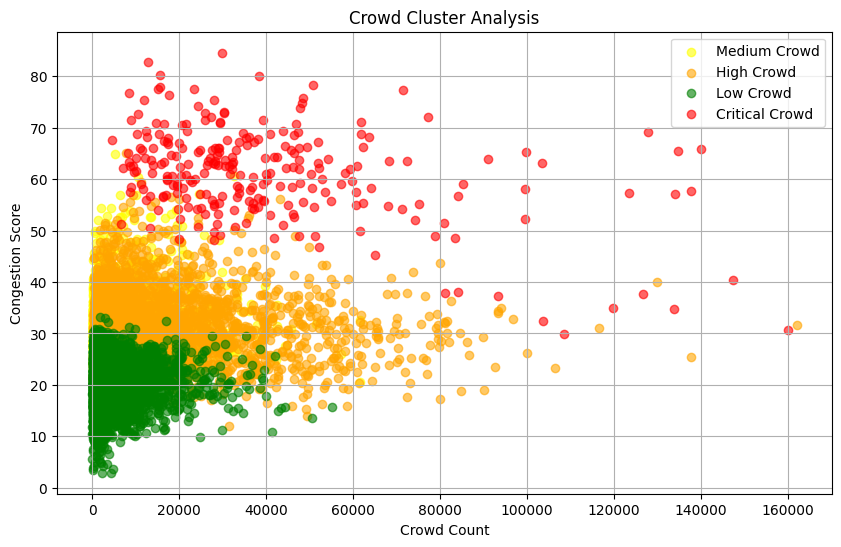

In [689]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

colors = {
    "Low Crowd": "green",
    "Medium Crowd": "yellow",
    "High Crowd": "orange",
    "Critical Crowd": "red"
}

for cluster in df["Cluster_Name"].unique():

    temp = df[df["Cluster_Name"] == cluster]

    plt.scatter(
        temp["crowd_count"],
        temp["congestion_score"],
        label=cluster,
        color=colors[cluster],
        alpha=0.6
    )

plt.xlabel("Crowd Count")
plt.ylabel("Congestion Score")
plt.title("Crowd Cluster Analysis")

plt.legend()

plt.grid(True)

plt.show()

In [690]:
import pickle

with open("crowd_cluster_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

with open("cluster_scaler.pkl", "wb") as file:
    pickle.dump(cluster_scaler, file)

In [691]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    cluster_scaled,
    df["Crowd_Cluster"]
)

print("Silhouette Score :", score)

Silhouette Score : 0.2459612834047874


In [692]:
from sklearn.metrics import davies_bouldin_score

db = davies_bouldin_score(
    cluster_scaled,
    df["Crowd_Cluster"]
)

print("Davies-Bouldin Index :", db)

Davies-Bouldin Index : 1.2130626148913395
